### site_validation for 1D


In [2]:
import os
import numpy as np
from mt_metadata.transfer_functions import TF

def is_1d_site(edi_path, skew_threshold=0.2):
    """Check if an EDI file represents a 1D-like site using Swift skew."""
    try:
        edi_obj = TF()
        edi_obj.read(fn=edi_path)
        Z = np.array(edi_obj.impedance.data)
        freq = np.array(edi_obj.frequency)

        # Compute Swift skew
        Zxx, Zxy, Zyx, Zyy = Z[:,0,0], Z[:,0,1], Z[:,1,0], Z[:,1,1]
        skew = np.abs(Zxx + Zyy) / np.abs(Zxy - Zyx)
        valid_ratio = np.sum(skew < skew_threshold) / len(skew)

        # Consider site 1D if 80% of frequencies have skew < threshold
        return valid_ratio >= 0.8, valid_ratio, np.nanmean(skew)
    except Exception as e:
        print(f"Error reading {edi_path}: {e}")
        return False, 0, np.nan

# ---- MAIN ----
data_folder = "../data/Barotse Basin, Western Province, Zambia"  # change this to your directory path
results = []

for file in os.listdir(data_folder):
    if file.endswith(".edi"):
        path = os.path.join(data_folder, file)
        is1D, ratio, mean_skew = is_1d_site(path)
        results.append((file, is1D, ratio, mean_skew))

# ---- Summary ----
print("\n=== 1D Site Screening Summary ===")
for f, is1D, ratio, mean_skew in results:
    status = "1D-LIKE" if is1D else "Not 1D"
    print(f"{f:25s} | {status:8s} | skew<0.2 ratio={ratio:.2f} | mean_skew={mean_skew:.2f}")

# Optional: Save to CSV
import pandas as pd
df = pd.DataFrame(results, columns=["Site", "Is1D", "ValidRatio", "MeanSkew"])
df.to_csv("1D_site_check.csv", index=False)


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data/Barotse Basin, Western Province, Zambia'

In [6]:
import os
import re
import numpy as np
import pandas as pd
from mt_metadata.transfer_functions import TF

def get_sitename(edi_path):
    with open(edi_path, "r", errors="ignore") as f:
        for line in f:
            if "SITENAME" in line:
                return line.split("=")[1].strip().strip('"')
    return os.path.basename(edi_path).split(".")[0]

def sanitize_edi(edi_path):
    """
    Clean EDI file text before reading:
    - Replace '**', '***', '****' → '-9999'
    - Replace isolated ' 0.0 ' inside data sections → '-9999'
    """
    with open(edi_path, "r", errors="ignore") as f:
        lines = f.readlines()

    cleaned = []
    for line in lines:
        if line.strip().startswith(">!"):  # keep comments
            cleaned.append(line)
            continue

       
        line = re.sub(r"\*+", " -9999 ", line)
        line = re.sub(r"(?<![0-9eE\+\-])0\.0(?![0-9eE\+\-])", " -9999 ", line)
        cleaned.append(line)

    return "".join(cleaned)


def compute_skew(edi_path):
    try:
        txt = sanitize_edi(edi_path)
        tmpfile = "_tmp_clean.edi"
        with open(tmpfile, "w", errors="ignore") as f:
            f.write(txt)

        tf = TF()
        tf.read(fn=tmpfile)
        Z = np.array(tf.impedance.data, dtype=float)
        Z[Z == -9999] = np.nan
        Zxx, Zxy, Zyx, Zyy = Z[:,0,0], Z[:,0,1], Z[:,1,0], Z[:,1,1]
        skew = np.abs(Zxx + Zyy) / np.abs(Zxy - Zyx)
        skew = skew[np.isfinite(skew)]

        if len(skew) == 0:
            return np.nan
        return np.nanmean(skew)
    except Exception:
        return np.nan

folder = "../data/all_station_EDI_data"
records, invalid_counter = [], {}

for f in os.listdir(folder):
    if f.lower().endswith(".edi"):
        path = os.path.join(folder, f)
        site = get_sitename(path)
        val = compute_skew(path)
        if np.isnan(val):
            invalid_counter[site] = invalid_counter.get(site, 0) + 1
        records.append((site, f, val))

df = pd.DataFrame(records, columns=["Site", "File", "MeanSkew"])

def ratio_low_skew(skews):
    valid = skews[~np.isnan(skews)]
    if len(valid) == 0:
        return 0
    return np.sum(valid < 0.2) / len(valid)

site_summary = (
    df.groupby("Site")["MeanSkew"]
    .agg(["mean", ratio_low_skew])
    .reset_index()
)

site_summary = (
    df.groupby("Site", as_index=False)["MeanSkew"]
      .mean()
      .rename(columns={"MeanSkew": "MeanSkew"})
)


site_summary["Is1D_like"] = site_summary["MeanSkew"] < 0.3

# sort best (lowest skew) to worst (highest skew)
site_summary = site_summary.sort_values("MeanSkew", ascending=True).reset_index(drop=True)

print(site_summary.to_string(index=False))

# save outputs
site_summary.to_csv("site_skew_summary.csv", index=False)
pd.Series(invalid_counter, name="IgnoredCount").to_csv("ignored_counts.csv")


C:\Users\shail\AppData\Local\Temp\ipykernel_8600\3821295074.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_8600\3821295074.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_8600\3821295074.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_8600\3821295074.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_8600\3821295074.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_8600\382129

                                   Site  MeanSkew  Is1D_like
        Kang to Ghazi, Botswana, Africa  0.103346       True
               Central Botswana, Africa  0.110974       True
              Kweneng, Botswana, Africa  0.148348       True
    Makgadikgadi Park, Botswana, Africa  0.149585       True
Kalahari Game Reserve, Botswana, Africa  0.220361       True
               Smithfield, South Africa  0.233682       True
                  Weiveld, South Africa  0.238262       True
            Coffiefontain, South Africa  0.245331       True
               Tshane, Botswana, Africa  0.290063       True
                Orapa, Botswana, Africa  0.308026      False
         Hardap Region, Namibia, Africa  0.488457      False
               Northern Namibia, Africa  0.516205      False
        Okavango Lake, Botswana, Africa  0.595121      False
                     NE Namibia, Africa  0.642600      False
                        Namibia, Africa  0.723177      False
              Windhoek, 

C:\Users\shail\AppData\Local\Temp\ipykernel_8600\3821295074.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)


In [2]:
len(records)

784


Plotting Swift Skew curves for 1D-like sites:
['Kang to Ghazi, Botswana, Africa', 'Central Botswana, Africa', 'Kweneng, Botswana, Africa', 'Makgadikgadi Park, Botswana, Africa', 'Kalahari Game Reserve, Botswana, Africa', 'Smithfield, South Africa', 'Weiveld, South Africa', 'Coffiefontain, South Africa', 'Tshane, Botswana, Africa']


C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\190783

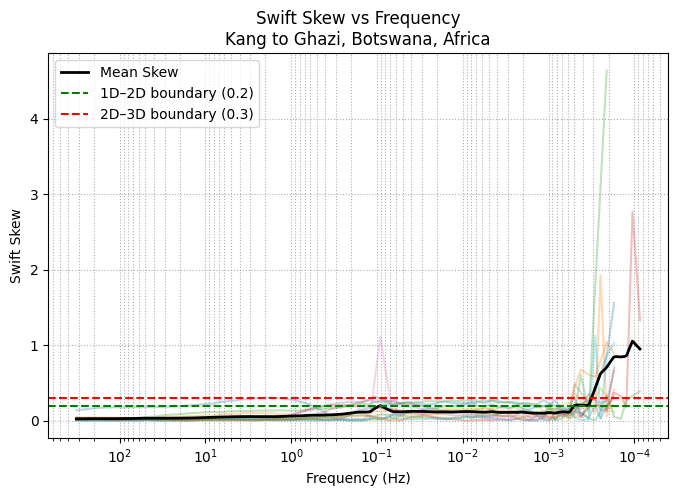

C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\190783

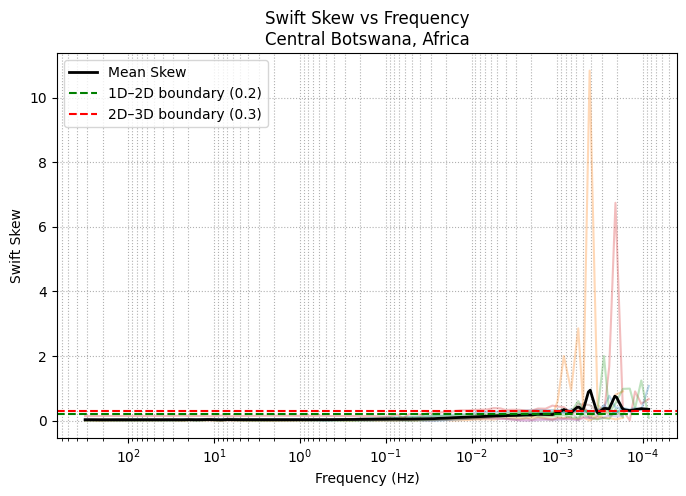

C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\190783

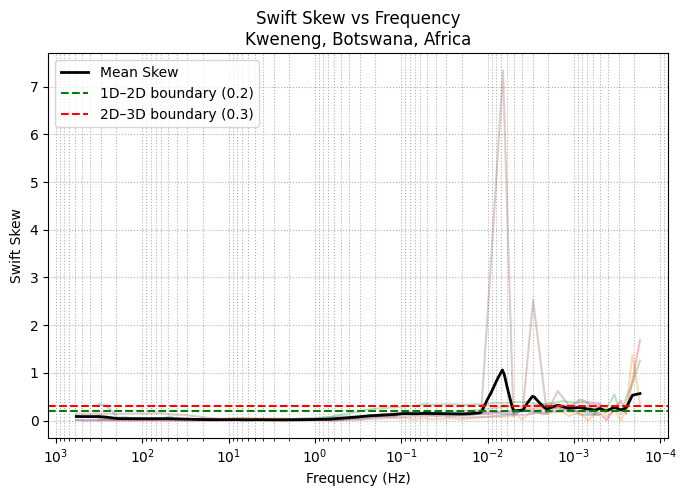

C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\190783

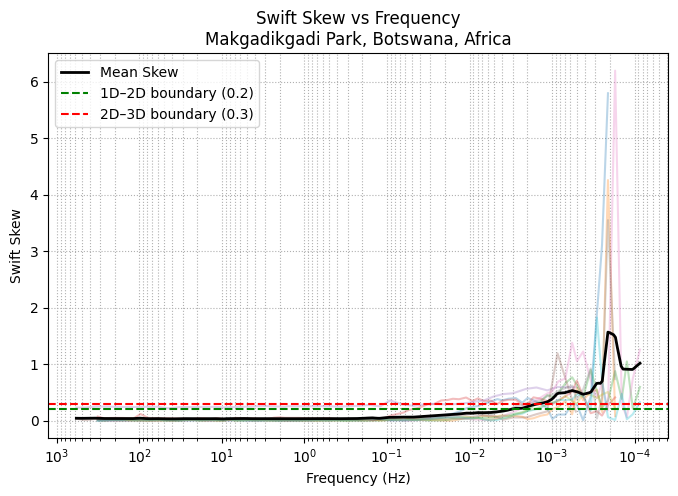

C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\190783

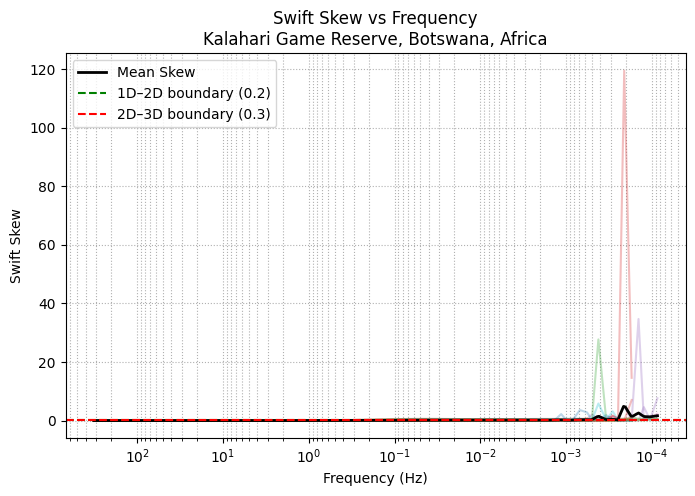

C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\190783

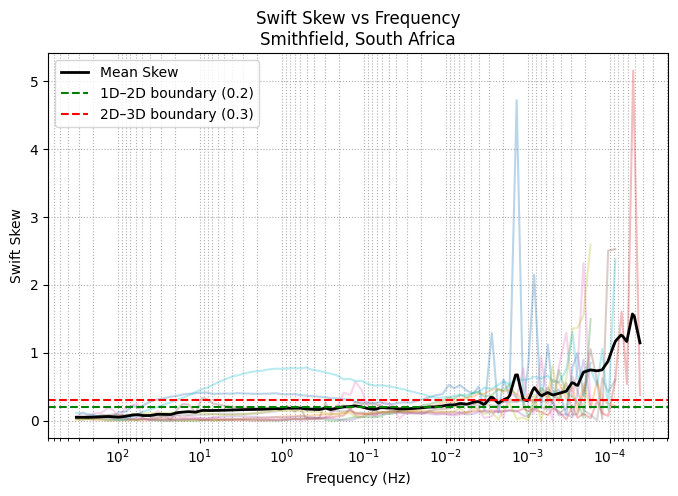

C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\190783

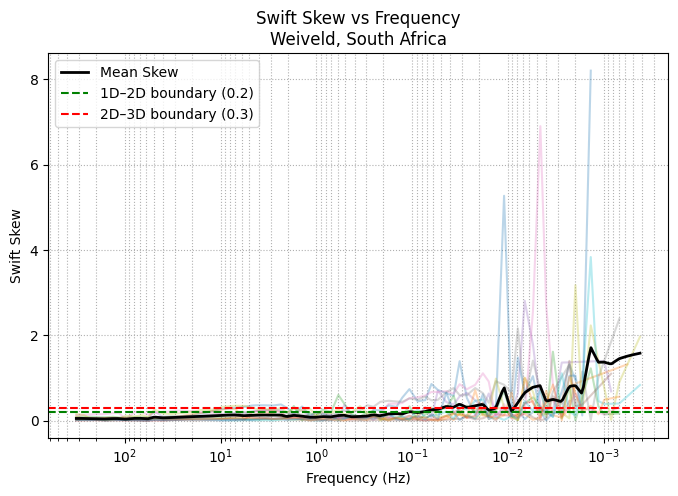

C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:24: RuntimeWarning: invalid value encountered in divide
  skew = np.abs(Zxx + Zyy) / np.abs(Zxy - Zyx)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarn

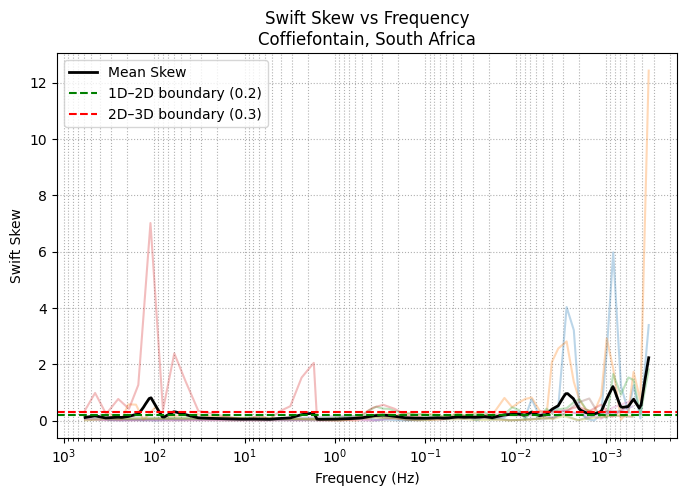

C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\1907832872.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_3788\190783

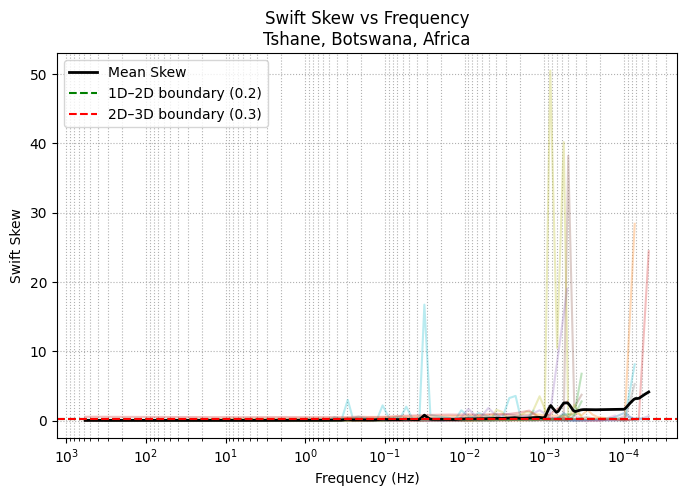

In [3]:
import matplotlib.pyplot as plt

# ---------- function to compute full skew curve ----------
def compute_skew_curve(edi_path):
    """Return frequency array and Swift skew array for plotting."""
    try:
        txt = sanitize_edi(edi_path)
        tmpfile = "_tmp_clean.edi"
        with open(tmpfile, "w", errors="ignore") as f:
            f.write(txt)

        tf = TF()
        tf.read(tmpfile)

        freq = np.array(tf.frequency)
        Z = np.array(tf.impedance.data, dtype=float)
        Z[Z == -9999] = np.nan

        Zxx = Z[:, 0, 0]
        Zxy = Z[:, 0, 1]
        Zyx = Z[:, 1, 0]
        Zyy = Z[:, 1, 1]

        skew = np.abs(Zxx + Zyy) / np.abs(Zxy - Zyx)

        mask = np.isfinite(freq) & np.isfinite(skew)
        return freq[mask], skew[mask]

    except:
        return None, None


# ================================
#     PLOT ONLY 1D-LIKE SITES
# ================================
one_d_sites = site_summary[site_summary["Is1D_like"] == True]["Site"]

print("\nPlotting Swift Skew curves for 1D-like sites:")
print(one_d_sites.to_list())

for site in one_d_sites:
    site_files = df[df["Site"] == site]["File"]

    plt.figure(figsize=(8, 5))
    plt.title(f"Swift Skew vs Frequency\n{site}", fontsize=12)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Swift Skew")
    plt.grid(True, which="both", linestyle=":")

    all_curves = []

    # plot each station file with light curves
    for fname in site_files:
        path = os.path.join(folder, fname)
        freq, skew = compute_skew_curve(path)
        if freq is None:
            continue

        all_curves.append((freq, skew))
        plt.semilogx(freq, skew, alpha=0.3)  # per-station faint curves

    # plot mean curve for site
    if len(all_curves) > 0:
        # Get global min/max frequency across all stations
        fmin = min(curve[0].min() for curve in all_curves)
        fmax = max(curve[0].max() for curve in all_curves)
        common_freq = np.logspace(np.log10(fmin), np.log10(fmax), 300)

        stack = []
        for f, s in all_curves:
            # interp requires descending freq → EDI files are often descending
            order = np.argsort(f)
            f_sorted = f[order]
            s_sorted = s[order]
            s_interp = np.interp(common_freq, f_sorted, s_sorted)
            stack.append(s_interp)

        mean_curve = np.nanmean(stack, axis=0)
        plt.semilogx(common_freq, mean_curve, color="black", linewidth=2, label="Mean Skew")

    # add 1D–2D and 2D–3D boundaries
    plt.axhline(0.2, color="green", linestyle="--", label="1D–2D boundary (0.2)")
    plt.axhline(0.3, color="red", linestyle="--", label="2D–3D boundary (0.3)")
    plt.legend()
    plt.gca().invert_xaxis()

    plt.show()


In [ ]:
!pip install cartopy
!pip install shapely


   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------- ----------------- 6.3/11.0 MB 31.7 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 29.0 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------  6.3/6.3 MB 35.0 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 26.9 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 8.1 MB/s  0:00:00

   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ----


1D-like site locations:
                                      Site        Lat        Lon
0                 Central Botswana, Africa -22.194260  24.162474
1              Coffiefontain, South Africa -28.625938  25.462590
2  Kalahari Game Reserve, Botswana, Africa -22.296449  23.862916
3          Kang to Ghazi, Botswana, Africa -22.784582  22.064056
4                Kweneng, Botswana, Africa -23.916770  24.977569
5      Makgadikgadi Park, Botswana, Africa -20.189296  25.178826
6                 Smithfield, South Africa -30.853458  27.182788
7                 Tshane, Botswana, Africa -23.936773  21.568215
8                    Weiveld, South Africa -27.012631  27.695640


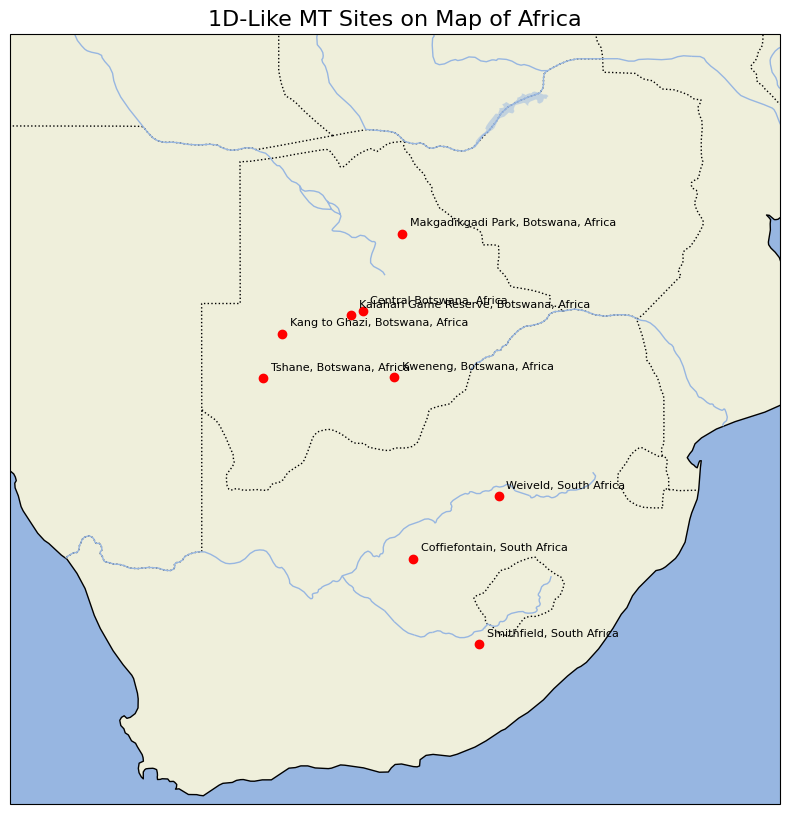

In [7]:
import re
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ----------------------------------------------------
# EXTRACT LAT / LONG FROM EACH EDI FILE
# ----------------------------------------------------
def extract_lat_lon(edi_path):
    """
    Reads LAT and LONG fields from HEAD section of EDI file.
    Converts DMS format (e.g., -17:22:58.10) to decimal degrees.
    """

    def dms_to_dd(dms):
        # Example: "-17:22:58.10"
        try:
            sign = -1 if dms.strip().startswith("-") else 1
            parts = dms.replace("-", "").split(":")
            deg, minutes, seconds = map(float, parts)
            return sign * (deg + minutes/60 + seconds/3600)
        except:
            return np.nan

    lat, lon = np.nan, np.nan

    with open(edi_path, "r", errors="ignore") as f:
        for line in f:
            if line.strip().startswith("LAT="):
                lat_str = line.split("=")[1].strip()
                lat = dms_to_dd(lat_str)
            if line.strip().startswith("LONG="):
                lon_str = line.split("=")[1].strip()
                lon = dms_to_dd(lon_str)

    return lat, lon


# ----------------------------------------------------
# BUILD TABLE: site, filename, meanSkew, lat, lon
# ----------------------------------------------------
records_with_geo = []

for idx, row in df.iterrows():
    site = row["Site"]
    fname = row["File"]
    path = os.path.join(folder, fname)

    lat, lon = extract_lat_lon(path)
    records_with_geo.append((site, fname, row["MeanSkew"], lat, lon))

geo_df = pd.DataFrame(records_with_geo, columns=["Site", "File", "MeanSkew", "Lat", "Lon"])

# ----------------------------------------------------
# GET ONLY 1D-LIKE SITES
# ----------------------------------------------------
good_sites = site_summary[site_summary["Is1D_like"] == True]["Site"].tolist()

good_geo = geo_df[geo_df["Site"].isin(good_sites)]

# Compute mean lat/lon per site
good_site_locations = (
    good_geo.groupby("Site")[["Lat", "Lon"]]
    .mean()
    .reset_index()
)

print("\n1D-like site locations:")
print(good_site_locations)


# ----------------------------------------------------
# PLOT ON MAP OF AFRICA
# ----------------------------------------------------
plt.figure(figsize=(10, 10))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([15, 35, -35, -15])  


ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# Plot each site
for _, row in good_site_locations.iterrows():
    plt.plot(row["Lon"], row["Lat"], 'ro', markersize=6, transform=ccrs.PlateCarree())
    plt.text(row["Lon"] + 0.2, row["Lat"] + 0.2, row["Site"], transform=ccrs.PlateCarree(), fontsize=8)

plt.title("1D-Like MT Sites on Map of Africa", fontsize=16)
plt.show()


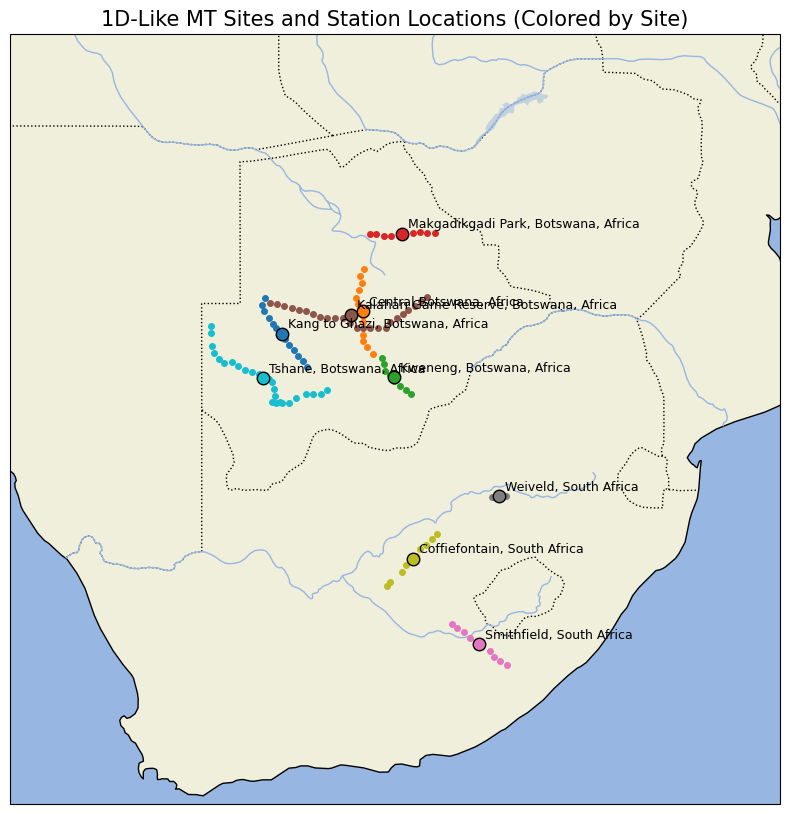

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --------------------------
# ZOOMED MAP EXTENT (Southern Africa)
# --------------------------
ZOOM_EXTENT = [15, 35, -35, -15]

# --------------------------
# 1D-LIKE SITES
# --------------------------
good_sites = site_summary[site_summary["Is1D_like"] == True]["Site"].tolist()

good_geo = geo_df[geo_df["Site"].isin(good_sites)]
site_centers = (
    good_geo.groupby("Site")[["Lat", "Lon"]].mean().reset_index()
)

# --------------------------
# ASSIGN UNIQUE COLOR TO EACH SITE
# --------------------------
colors = list(cm.tab10(np.linspace(0, 1, len(good_sites))))
site_color_map = dict(zip(good_sites, colors))

# --------------------------
# PLOT MAP
# --------------------------
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(ZOOM_EXTENT)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# --------------------------
# PLOT ALL STATIONS (color-coded by site)
# --------------------------
for _, row in good_geo.iterrows():
    site = row["Site"]
    color = site_color_map[site]

    ax.plot(row["Lon"], row["Lat"],
            marker='o',
            markersize=4,
            color=color,
            transform=ccrs.PlateCarree())

# --------------------------
# PLOT SITE CENTERS (bigger + label)
# --------------------------
for _, row in site_centers.iterrows():
    site = row["Site"]
    color = site_color_map[site]

    ax.plot(row["Lon"], row["Lat"],
            marker='o',
            markersize=9,
            color=color,
            markeredgecolor='black',
            transform=ccrs.PlateCarree())

    ax.text(row["Lon"] + 0.15, row["Lat"] + 0.15,
            site,
            fontsize=9,
            transform=ccrs.PlateCarree())

plt.title("1D-Like MT Sites and Station Locations (Colored by Site)", fontsize=15)
plt.show()


ImportError: cannot import name 'XYZTileSource' from 'cartopy.io.img_tiles' (d:\Dissertation\venv\Lib\site-packages\cartopy\io\img_tiles.py)